# 04 - Accretion History (~5 Myr → 100 Myr)

This notebook reconstructs the post-gas-disk accretion history of planetary embryos using N-body simulation data and collision records.

It covers:
- Loading N-body simulation snapshots and identifying final planets (m ≥ 0.05 M⊕)
- Tracking mass evolution of each planet across all time steps
- Loading collision records and filtering events **after** the gas disk phase (t > 5 Myr)
- Tracing full collision histories using `CollisionTracer` for each planet
- Visualizing planet mass evolution (full simulation & post-gas-disk) with bubble-size scatter plots
- Exporting collision history tables to Excel

> **Prerequisites:** Run `01_constants_and_setup.ipynb`, `02_meteorite_bulk_composition.ipynb`, and `03_embryo_bulk_composition.ipynb` first.  
> **Input:** N-body `aei` snapshots + `Collision` file  
> **Output:** `./Tables/04_accretion_history.xlsx`

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import sys
import matplotlib.patches as mpatches
sys.path.append('../../src')
import accrediff as ad

# ── Plot style ──────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "figure.dpi": 150,
    "xtick.major.size": 8,
    "xtick.minor.size": 5,
    "xtick.major.width": 1.3,
    "xtick.minor.width": 1.0,
})

print("Setup complete.")

Setup complete.


## 1. Load N-body Simulation Data

Read all `aei` snapshot files from the selected model directory.  
Each snapshot contains orbital elements and masses for all particles at a given time step (0.1 Myr interval).

- Mass is converted from solar units to Earth mass units (`m_e = m / ME`)
- Particle index `i` is used as the DataFrame index for cross-snapshot tracking

In [2]:
# ── Model selection ──────────────────────────────────────
model = 'note_02'
Path  = f'../dataset/N_body_dataset/{model}/'

# ── Load all aei snapshots ───────────────────────────────
file_paths = sorted(
    [os.path.join(Path, f) for f in os.listdir(Path) if f.startswith('aei')]
)
keys = [f'{i/10:.1f} Myr' for i in range(len(file_paths))]

col_names = ['t', 'i', 'a', 'e', 'inc', 'Omega', 'w', 'T', 'E', 'M', 'm', 'r']
A_dict = {}
for path, key in zip(file_paths, keys):
    A_dict[key] = pd.read_csv(
        path, sep=' ', header=None, names=col_names, index_col='i'
    )

# Convert mass to Earth units
for key in A_dict:
    A_dict[key]['m_e'] = A_dict[key]['m'] / ad.constants.ME
    A_dict[key]['N']   = len(A_dict[key])

print(f"Model     : {model}")
print(f"Snapshots : {len(A_dict)}")
print(f"Time range: {list(A_dict.keys())[0]} → {list(A_dict.keys())[-1]}")

Model     : note_02
Snapshots : 1001
Time range: 0.0 Myr → 100.0 Myr


## 2. Identify Final Planets (t = 100 Myr)

Planets are defined as particles with mass ≥ 0.05 M⊕ at the **final** simulation snapshot.  
The two giant planets (index 0 and 1) are excluded.  
Planets are sorted by mass (descending) and assigned sequential IDs (`planets_1`, `planets_2`, ...).

In [3]:
time_end      = keys[-1]
df_end        = A_dict[time_end][['a', 'e', 'inc', 'm_e']].iloc[2:]   # remove giant planets
df_planet     = (
    df_end[df_end['m_e'] >= 0.05]
    .sort_values('m_e', ascending=False)
)
planets_index = df_planet.index.tolist()
keys_planets  = [f'planets_{i+1}' for i in range(len(planets_index))]

print(f"Final snapshot : {time_end}")
print(f"Planets found  : {len(planets_index)}")
df_planet[['a', 'e', 'inc', 'm_e']]

Final snapshot : 100.0 Myr
Planets found  : 3


,a,e,inc,m_e
i,,,,
4189,1.106465,0.023236,0.019801,0.841635
2768,1.581875,0.027334,0.019516,0.353523
4755,1.781888,0.073278,0.047978,0.081899


## 3. Track Mass Evolution Across All Snapshots

For each time step, extract the semi-major axis (`a`) and mass (`m_e`) of each identified planet.  
Results are stored in `df_history` with columns `a_1`, `m_1`, `a_2`, `m_2`, ...  
A `Time` column (in Myr) is added for plotting.  
Particles that have been ejected or merged at a given snapshot are filled with `NaN`.

In [4]:
columns    = [f'{prefix}_{i+1}' for i in range(len(planets_index)) for prefix in ('a', 'm')]
df_history = pd.DataFrame(columns=columns)

for t in A_dict.keys():
    df_snap = A_dict[t][['a', 'm_e']].iloc[2:]
    planets = df_snap.reindex(planets_index)[['a', 'm_e']]
    df_history.loc[len(df_history)] = planets.values.flatten().tolist()

df_history['Time'] = [float(k.replace(' Myr', '')) for k in A_dict.keys()]
df_history = df_history.astype(float)

print(f"df_history shape: {df_history.shape}")
df_history.head()

df_history shape: (1001, 7)


,a_1,m_1,a_2,m_2,a_3,m_3,Time
0,1.040795,0.001103,1.012541,0.000948,1.023094,0.001116,0.0
1,0.896576,0.008478,0.939617,0.009271,1.140008,0.005766,0.1
2,0.807675,0.009152,0.957055,0.011751,1.160407,0.006465,0.2
3,0.984793,0.009152,0.945437,0.013761,1.162225,0.007070,0.3
4,0.986004,0.011538,0.923924,0.028618,1.222259,0.007070,0.4


## 4. Visualize Mass Evolution (Full Simulation: 0 → 100 Myr)

Plot mass evolution of each planet over the full simulation.  
- Dashed lines connect snapshots
- Scatter markers appear every 5 Myr; marker size scales with planet mass
- The gas disk end time (5 Myr) is marked with a vertical dashed line

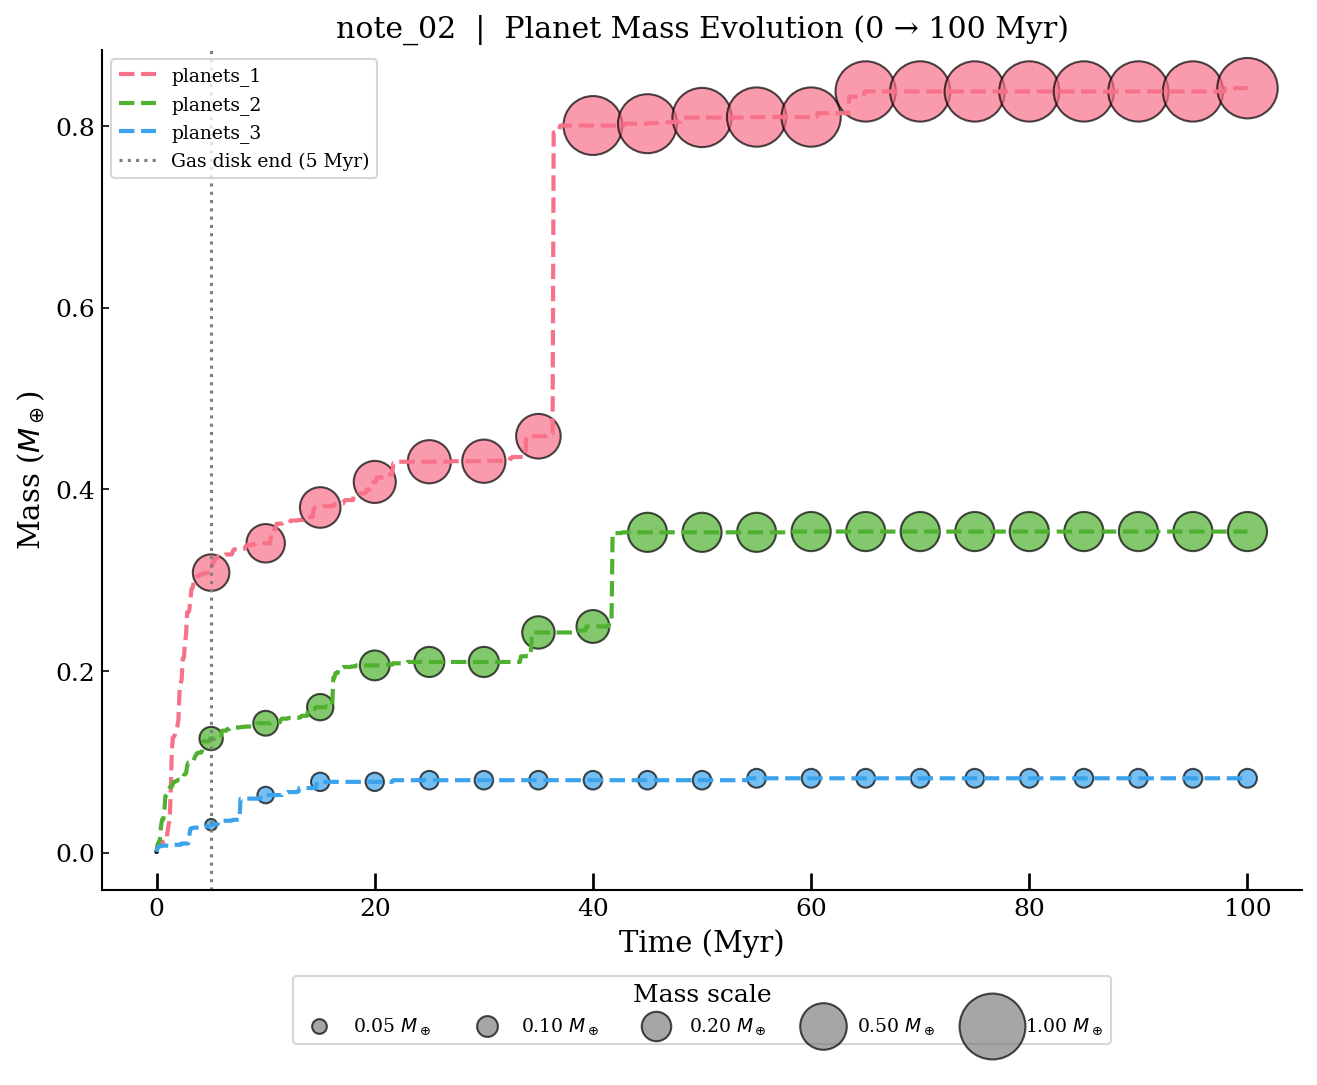

In [5]:
m_cols = [col for col in df_history.columns if col.startswith('m_')]
colors = sns.color_palette("husl", n_colors=len(m_cols))

fig = plt.figure(figsize=(10, 8))
ax  = fig.add_axes([0.1, 0.2, 0.8, 0.7])

for i, col in enumerate(m_cols):
    ax.plot(df_history['Time'], df_history[col],
            linestyle='--', linewidth=2, color=colors[i], label=keys_planets[i])
    mask = (np.round(df_history['Time'] % 5, 6) == 0)
    ax.scatter(df_history['Time'][mask], df_history[col][mask],
               s=df_history[col][mask] * 1000,
               color=colors[i], alpha=0.7, edgecolors='k')

ax.axvline(5.0, color='gray', linestyle=':', linewidth=1.5, label='Gas disk end (5 Myr)')
ax.set_xlabel('Time (Myr)')
ax.set_ylabel('Mass ($M_\\oplus$)')
ax.set_title(f'{model}  |  Planet Mass Evolution (0 → 100 Myr)')
ax.legend(loc='upper left', fontsize=9, frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Mass size legend ─────────────────────────────────────
sizes   = [0.05, 0.10, 0.20, 0.50, 1.00]
handles = [plt.scatter([], [], s=s*1000, color='gray', alpha=0.7, edgecolors='k') for s in sizes]
labels  = [f'{s:.2f} $M_\\oplus$' for s in sizes]
legend_ax = fig.add_axes([0.1, 0.05, 0.8, 0.10])
legend_ax.axis('off')
legend_ax.legend(handles, labels, loc='center', ncol=len(sizes),
                 frameon=True, title='Mass scale', fontsize=9)

plt.show()

## 5. Load Collision Records & Filter Post-Gas-Disk Phase

Collision events are read from the `Collision` file.  
Only collisions occurring **after** the gas disk lifetime (t > 5 Myr) are retained for post-disk accretion analysis.  
`ad.resolve_product_id()` determines which particle survives each collision event.

In [6]:
# ── Locate collision file ────────────────────────────────
collision_files = [
    os.path.join(Path, f) for f in os.listdir(Path) if f.startswith('Collision')
]
if not collision_files:
    raise FileNotFoundError(f"No Collision file found in {Path}")

col_names_c = [
    'time',
    'indexi', 'mi', 'ri', 'xi', 'yi', 'zi', 'vxi', 'vyi', 'vzi', 'Sxi', 'Syi', 'Szi',
    'indexj', 'mj', 'rj', 'xj', 'yj', 'zj', 'vxj', 'vyj', 'vzj', 'Sxj', 'Syj', 'Szj',
]

C_data = pd.read_csv(collision_files[0], sep=r'\s+', header=None, names=col_names_c)
C_data['m_ei'] = C_data['mi'] / ad.constants.ME
C_data['m_ej'] = C_data['mj'] / ad.constants.ME

# Filter: post-gas-disk only
gas_time_yr = A_dict['5.0 Myr']['t'].iloc[0]
C_nogas     = C_data[C_data['time'] > gas_time_yr].copy()
C_nogas['product_id'] = C_nogas.apply(ad.resolve_product_id, axis=1)

collision_df = (
    C_nogas[['time', 'indexi', 'm_ei', 'indexj', 'm_ej', 'product_id']]
    .sort_values('time')
    .reset_index(drop=True)
)

print(f"Gas disk end      : {gas_time_yr:.0f} yr")
print(f"Total collisions  : {len(C_data)}")
print(f"Post-disk         : {len(collision_df)}")
collision_df.head()

Gas disk end      : 4928131 yr
Total collisions  : 5790
Post-disk         : 527


,time,indexi,m_ei,indexj,m_ej,product_id
0,4.929140e+06,6421,0.018042,6902,0.000814,6421.0
1,4.930942e+06,6604,0.001819,6829,0.000685,6604.0
2,4.935332e+06,6243,0.013290,4586,0.000978,6243.0
3,4.937856e+06,4189,0.308318,6654,0.000834,4189.0
4,4.938910e+06,3901,0.016796,2384,0.002257,3901.0


## 6. Trace Full Collision Histories

`CollisionTracer.trace_full_history()` reconstructs the complete merger tree for each final planet,
returning every collision event in its ancestry chain.

Results are stored in `dict_history` keyed by planet ID (`planets_1`, `planets_2`, ...).  
Each entry contains:
- `time` — collision time (yr)
- `Time` — collision time (Myr)
- `indexi`, `indexj` — colliding particle indices
- `m_ei`, `m_ej` — masses at collision (M⊕)
- `Mass` — total mass of the collision event (`m_ei + m_ej`)
- `product_id` — surviving particle index

In [7]:
tracer       = ad.CollisionTracer(collision_df)
dict_history = {}

for key, index in zip(keys_planets, planets_index):
    h = tracer.trace_full_history(index)
    h['Time'] = h['time'] / 1e6
    h['Mass'] = h['m_ei'] + h['m_ej']
    dict_history[key] = h

print("Collision history tracing complete.")
dict_history[keys_planets[0]].head()

Collision history tracing complete.


,time,indexi,m_ei,indexj,m_ej,product_id,Time,Mass
0,4.930942e+06,6604,0.001819,6829,0.000685,6604,4.930942,0.002504
1,4.935332e+06,6243,0.013290,4586,0.000978,6243,4.935332,0.014268
2,4.937856e+06,4189,0.308318,6654,0.000834,4189,4.937856,0.309152
3,4.964972e+06,6439,0.001084,5522,0.000907,6439,4.964972,0.001991
4,5.019652e+06,4189,0.309152,1955,0.009635,4189,5.019652,0.318787


## 7. Visualize Post-Gas-Disk Accretion Events

For each planet, plot only the collision events where that planet is the **product** (`product_id == index`).  
- X-axis: collision time (log scale, Myr)
- Y-axis: total mass at collision event (M⊕)
- Marker size scales with mass

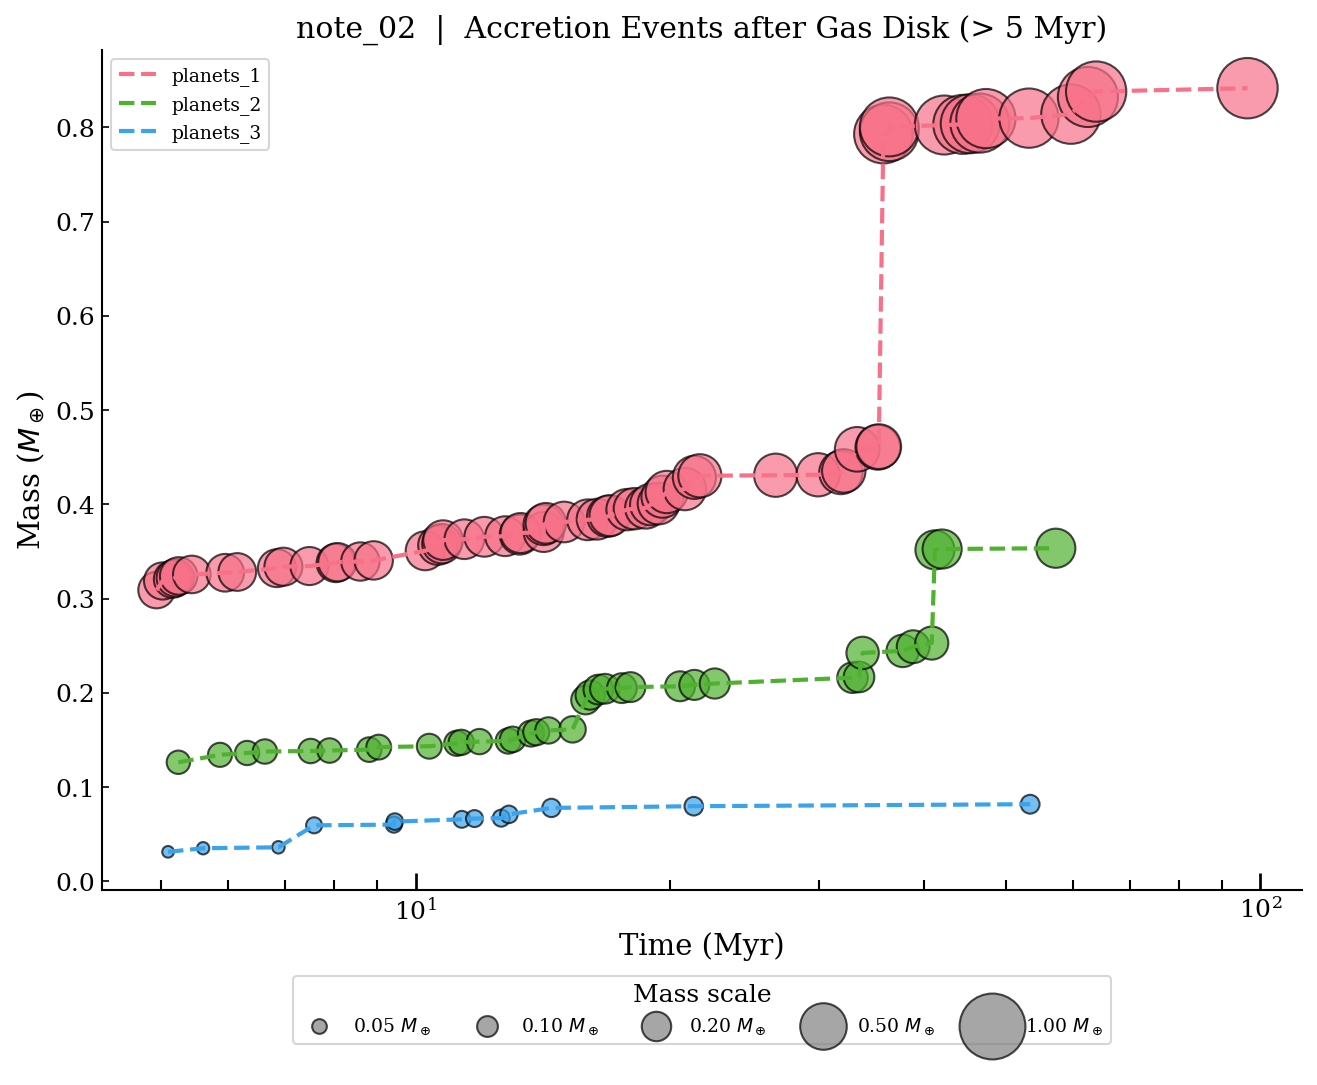

In [8]:
colors = sns.color_palette("husl", n_colors=len(keys_planets))

fig = plt.figure(figsize=(10, 8))
ax  = fig.add_axes([0.1, 0.2, 0.8, 0.7])

for i, (key, index) in enumerate(zip(keys_planets, planets_index)):
    df_p = dict_history[key][dict_history[key]['product_id'] == index]
    x, y = df_p['Time'], df_p['Mass']
    ax.plot(x, y, linestyle='--', linewidth=2, color=colors[i], label=key)
    ax.scatter(x, y, s=y * 1000, color=colors[i], alpha=0.7, edgecolors='k')

ax.set_xscale('log')
ax.set_xlabel('Time (Myr)')
ax.set_ylabel('Mass ($M_\\oplus$)')
ax.set_title(f'{model}  |  Accretion Events after Gas Disk (> 5 Myr)')
ax.legend(loc='upper left', fontsize=9, frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Mass size legend ─────────────────────────────────────
sizes   = [0.05, 0.10, 0.20, 0.50, 1.00]
handles = [plt.scatter([], [], s=s*1000, color='gray', alpha=0.7, edgecolors='k') for s in sizes]
labels  = [f'{s:.2f} $M_\\oplus$' for s in sizes]
legend_ax = fig.add_axes([0.1, 0.05, 0.8, 0.10])
legend_ax.axis('off')
legend_ax.legend(handles, labels, loc='center', ncol=len(sizes),
                 frameon=True, title='Mass scale', fontsize=9)

plt.show()

## 8. Export Collision Histories to Excel

Save each planet's full collision history as a separate sheet in an Excel file.  
The file is saved to `./Tables/04_accretion_history.xlsx`.

In [9]:
import pathlib

save_dir  = pathlib.Path('./Tables')
save_dir.mkdir(parents=True, exist_ok=True)

save_file = save_dir / '04_accretion_history.xlsx'
with pd.ExcelWriter(save_file) as writer:
    for key, df in dict_history.items():
        df.to_excel(writer, sheet_name=key, index=False)

print(f"Saved: {save_file}")

# Verify
D = pd.read_excel(save_file, sheet_name=None)
print(f"Sheets: {list(D.keys())}")

Saved: Tables/04_accretion_history.xlsx
Sheets: ['planets_1', 'planets_2', 'planets_3']


## 9. Summary

| Step | Operation | Output |
|------|-----------|--------|
| 1 | Load N-body snapshots | `A_dict` |
| 2 | Identify final planets (m ≥ 0.05 M⊕) | `df_planet`, `planets_index` |
| 3 | Track mass evolution across all snapshots | `df_history` |
| 4 | Visualize full mass evolution (0 → 100 Myr) | line + bubble plot |
| 5 | Load & filter post-disk collision records | `collision_df` |
| 6 | Trace full collision histories | `dict_history` |
| 7 | Visualize post-disk accretion events | log-scale bubble plot |
| 8 | Export to Excel | `./Tables/04_accretion_history.xlsx` |

➡️ **Next:** `05_differentiation.ipynb`